### Load necessary libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv('olympic100m.txt', header=None, names=['Year', 'Time'])
df.head()

,Year,Time
0,1896,12.0
1,1900,11.0
2,1904,11.0
3,1906,11.2
4,1908,10.8


Split data into training and test sets

In [23]:
# Predictor (must be 2D)
X = df[['Year']]

# Target / Response 
y = df['Time']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True, random_state=42)

### Fit the model

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
# Extract slope and intercept
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: -0.011738407832883649
Intercept: 33.27378362215238


The estimated regression model is given by: $\hat{y} = \omega_0 + \omega_1 * X$
where $\omega_0$ = bias = 33.2737
        and $\omega_1$ = slope = -0.01173 

### Make Predictions

In [42]:
y_pred = model.predict(X_test)

data = {"actual": y_test, "predicted": y_pred}

pred_df = pd.DataFrame(data)
pred_df

,actual,predicted
8,10.80,10.642133
13,10.50,10.313458
9,10.30,10.595180
21,9.92,9.937829
0,12.00,11.017762
11,10.30,10.407365


### Scatterplot and abline between X and y

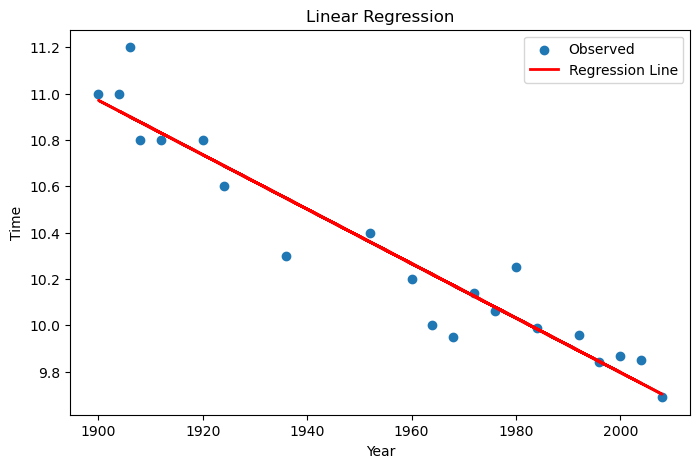

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, label="Observed")
plt.plot(X_train, model.predict(X_train), color="red",
         linewidth=2, label="Regression Line")

plt.xlabel("Year")
plt.ylabel("Time")
plt.title("Linear Regression")
plt.legend()

plt.show()

### Performance of the model on the test set

In [43]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 0.1872
RMSE : 0.4327
R²   : 0.5751


In [44]:
y_pred_train = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"R²   : {r2_train:.4f}")

MSE  : 0.0166
RMSE : 0.1289
R²   : 0.9153


In [46]:
dta = {"Train": {"MSE": 0.0166, "RMSE": 0.1289, "R_squared": 0.9153}, 
       "Test": {"MSE": 0.1872, "RMSE": 0.4327, "R_squared": 0.5751}}
final_df = pd.DataFrame(dta)
final_df

,Train,Test
MSE,0.0166,0.1872
RMSE,0.1289,0.4327
R_squared,0.9153,0.5751


The results shows that the model is overfitting because the model performs better using the training set. To solve this problem, we may need to apply some regularization techniques such as L1 or L2 regularization to solve the problem of overfitting.